<div align="center" style="padding: 20px; border-radius: 10px; background-color: #f8f9fa; margin-bottom: 20px; border: 1px solid #e9ecef;">
<!-- Photo de Profil / Logo GitHub -->
<a href="https://github.com/KING-EMBBI" target="_blank" style="text-decoration: none;">
<img src="https://avatars.githubusercontent.com/u/181809601?s=400&u=0ae861f86d8d365864862c4d68aef5d1e9ebf1f4&v=4" alt="Osee Emmanuel Boum Bissemb" style="width: 140px; height: 140px; border-radius: 50%; border: 3px solid #2e7d32; object-fit: cover; box-shadow: 0 4px 8px rgba(0,0,0,0.1);"/>
</a>
<br><br>
<!-- Informations Personnelles -->
<span style="color: #1a252f; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; font-size: 28px; font-weight: 800; letter-spacing: 1px; text-transform: uppercase;">Osee Emmanuel Boum Bissemb</span>
<br>
<span style="color: #2e7d32; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; font-size: 16px; font-weight: 600; tracking-spacing: 0.5px;">🚀 Data Scientist & Analyste Statistique</span>
<hr style="width: 60%; border: 0; height: 1px; background-image: linear-gradient(to right, rgba(0, 0, 0, 0), rgba(46, 125, 50, 0.75), rgba(0, 0, 0, 0)); margin: 15px 0;"/>
<!-- Titre du Projet Évolutif -->
<span style="color: #111111; font-family: 'Impact', 'Arial Black', sans-serif; font-size: 22px; letter-spacing: 1.5px; text-transform: uppercase;">Telecom Churn Predictive Intelligence</span>
<br>
<span style="color: #555555; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 400; font-style: italic;">PHASE 6 — Explainability (XAI) & Transparence Algorithmique</span>
</div>


<div style='background-color: #2e7d32; padding: 6px;'></div>

<center style="background-color: white; padding:18px; color: #1a252f; font-family:'Tw Cen MT' sans-serif; font-size: 20px;">
 <strong> 🌍 1. Analyse Globale : Les Moteurs du Churn</strong> 
</center>

<div style="background-color: #ffffff; 
            padding: 30px 40px; 
            color: #2c3e50; 
            font-family: 'Calibri', 'Segoe UI', Arial, sans-serif; 
            font-size: 16px; 
            line-height: 1.6; 
            text-align: justify; 
            box-shadow: 0 4px 15px rgba(0,0,0,0.05); 
            border-radius: 4px; 
            margin: 20px 0; 
            border-left: 5px solid #2e7d32;">
    <!-- Premier Paragraphe : Corps du texte -->
    <p style="margin-bottom: 20px; text-indent: 30px;">
       Le modèle SHAP calcule la contribution de chaque variable à la prédiction finale par rapport à une valeur de base moyenne. Nous allons générer le Summary Plot, la visualisation ultime pour la direction marketing.
    </p>
 
</div>

🔮 Calcul des valeurs SHAP en cours (cela peut prendre quelques secondes)...


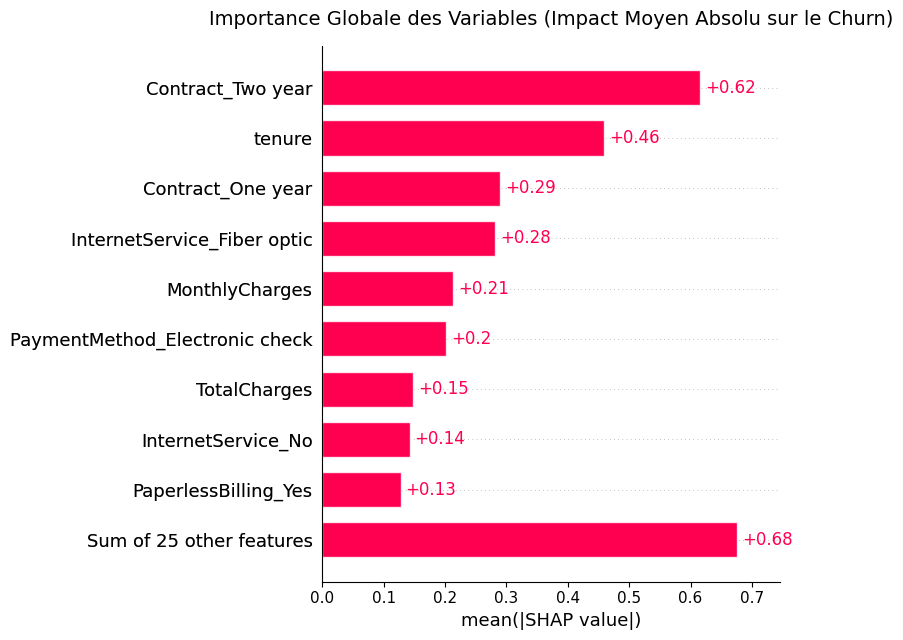

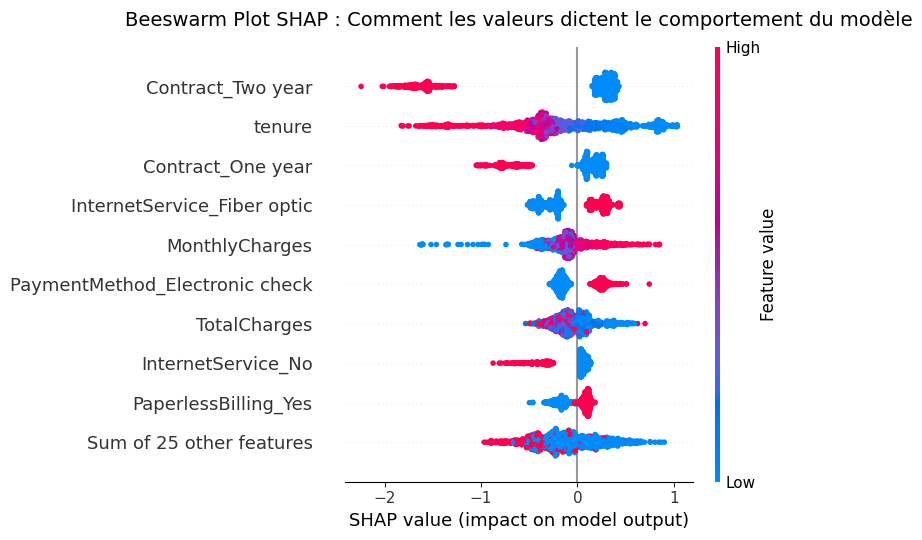

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
import shap

# 1. Rechargement express des données pour sécuriser la cellule
X_train = pd.read_csv("../TELECOM CHURN/data/X_train.csv")
X_test = pd.read_csv("../TELECOM CHURN/data/X_test.csv")
y_train = pd.read_csv("../TELECOM CHURN/data/y_train.csv").values.ravel()
y_test = pd.read_csv("../TELECOM CHURN/data/y_test.csv").values.ravel()

# 2. Re-instanciation et entraînement flash du modèle champion
ratio_imbalance = (len(y_train) - sum(y_train)) / sum(y_train)
champion_model = XGBClassifier(
    scale_pos_weight=ratio_imbalance, 
    n_estimators=150, 
    max_depth=4, 
    learning_rate=0.05, 
    random_state=42
)
champion_model.fit(X_train, y_train)

# 3. Calcul de l'explainer SHAP
print("🔮 Calcul des valeurs SHAP en cours (cela peut prendre quelques secondes)...")
explainer = shap.TreeExplainer(champion_model)
shap_values = explainer(X_test)

# 4. Génération du graphique d'importance globale (Bar Plot)
plt.figure(figsize=(10, 5))
shap.plots.bar(shap_values, max_display=10, show=False)
plt.title("Importance Globale des Variables (Impact Moyen Absolu sur le Churn)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# 2. Graphique Summary / Beeswarm Plot (Donne la direction de l'impact)
plt.figure(figsize=(11, 6))
plt.title("Beeswarm Plot SHAP : Comment les valeurs dictent le comportement du modèle", fontsize=14, pad=15)
shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.tight_layout()
plt.show()

<div style="background-color: #ffffff; 
            padding: 30px 40px; 
            color: #2c3e50; 
            font-family: 'Calibri', 'Segoe UI', Arial, sans-serif; 
            font-size: 16px; 
            line-height: 1.6; 
            text-align: justify; 
            box-shadow: 0 4px 15px rgba(0,0,0,0.05); 
            border-radius: 4px; 
            margin: 20px 0; 
            border-left: 5px solid #2e7d32;">
    <!-- Premier Paragraphe : Corps du texte -->
    <p style="margin-bottom: 20px; text-indent: 30px;">
       💡 Lecture du Beeswarm Plot :

Chaque point représente un client. La couleur indique si la valeur de sa variable est élevée (Rouge) ou faible (Bleu).

Un décalage vers la droite augmente la probabilité de churn (SHAP value > 0).

On y voit instantanément qu'un contrat de type Contract_One year ou Contract_Two year (en bleu, donc absent/faible car ce sont des indicatrices issues du One-Hot Encoding) pousse massivement vers la zone de danger à droite !
 
</div>


<center style="background-color: white; padding:18px; color: #1a252f; font-family:'Tw Cen MT' sans-serif; font-size: 20px;">
 <strong> 🔬 2. Analyse Locale (Micro) : Autopsie de Deux Profils Clients</strong> 
</center>

<div style="background-color: #ffffff; 
            padding: 30px 40px; 
            color: #2c3e50; 
            font-family: 'Calibri', 'Segoe UI', Arial, sans-serif; 
            font-size: 16px; 
            line-height: 1.6; 
            text-align: justify; 
            box-shadow: 0 4px 15px rgba(0,0,0,0.05); 
            border-radius: 4px; 
            margin: 20px 0; 
            border-left: 5px solid #2e7d32;">
    <!-- Premier Paragraphe : Corps du texte -->
    <p style="margin-bottom: 20px; text-indent: 30px;">
       Nous allons isoler deux clients réels de ta base de test pour générer des Waterfall Plots. Ces graphiques montrent précisément comment les caractéristiques individuelles s'additionnent ou se soustraient pour créer le score de risque final.
    </p>
 
</div>

In [4]:
# Calcul des probabilités de churn sur le jeu de test pour identifier nos profils types
test_prob = champion_model.predict_proba(X_test)[:, 1]

# Profil A : Client fidèle à très faible risque (Probabilité proche de 0)
low_risk_idx = np.argmin(test_prob)

# Profil B : Client récent à très haut risque (Probabilité proche de 1)
high_risk_idx = np.argmax(test_prob)

print(f"🔬 Profil Fidèle identifié à l'indice : {low_risk_idx} (Risque : {test_prob[low_risk_idx]*100:.2f}%)")
print(f"🔬 Profil Volatil identifié à l'indice : {high_risk_idx} (Risque : {test_prob[high_risk_idx]*100:.2f}%)\n")

🔬 Profil Fidèle identifié à l'indice : 1328 (Risque : 0.67%)
🔬 Profil Volatil identifié à l'indice : 1090 (Risque : 96.16%)



<div style="background-color: #ffffff; 
            padding: 30px 40px; 
            color: #2c3e50; 
            font-family: 'Calibri', 'Segoe UI', Arial, sans-serif; 
            font-size: 16px; 
            line-height: 1.6; 
            text-align: justify; 
            box-shadow: 0 4px 15px rgba(0,0,0,0.05); 
            border-radius: 4px; 
            margin: 20px 0; 
            border-left: 5px solid #2e7d32;">
    <!-- Premier Paragraphe : Corps du texte -->
    <p style="margin-bottom: 20px; text-indent: 30px;">
       🟢 Cas Client 1 : Le pilier de la base (Faible Risque)
    </p>
 
</div>

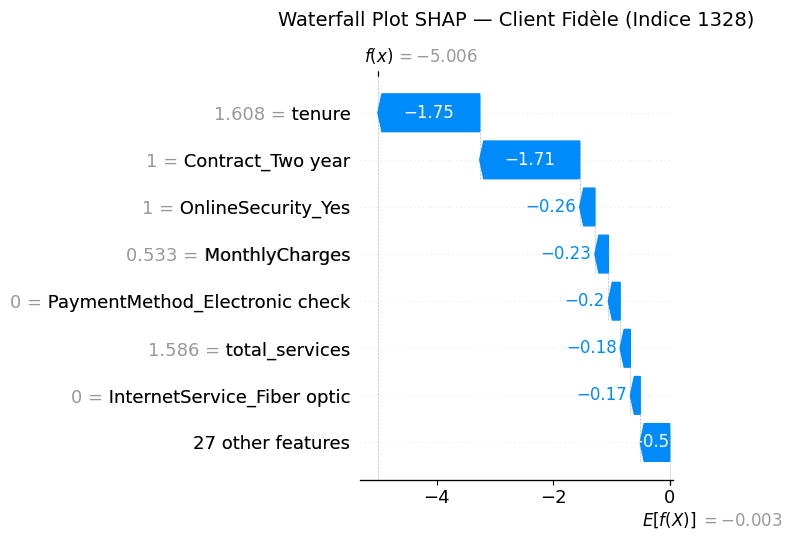

In [5]:
plt.figure(figsize=(12, 5))
plt.title(f"Waterfall Plot SHAP — Client Fidèle (Indice {low_risk_idx})", fontsize=14, pad=15)
shap.plots.waterfall(shap_values[low_risk_idx], max_display=8, show=False)
plt.tight_layout()
plt.show()

<div style="background-color: #ffffff; 
            padding: 30px 40px; 
            color: #2c3e50; 
            font-family: 'Calibri', 'Segoe UI', Arial, sans-serif; 
            font-size: 16px; 
            line-height: 1.6; 
            text-align: justify; 
            box-shadow: 0 4px 15px rgba(0,0,0,0.05); 
            border-radius: 4px; 
            margin: 20px 0; 
            border-left: 5px solid #2e7d32;">
    <!-- Premier Paragraphe : Corps du texte -->
    <p style="margin-bottom: 20px; text-indent: 30px;">
       🔴 Cas Client 2 : L'alerte rouge (Haut Risque)
 
</div>

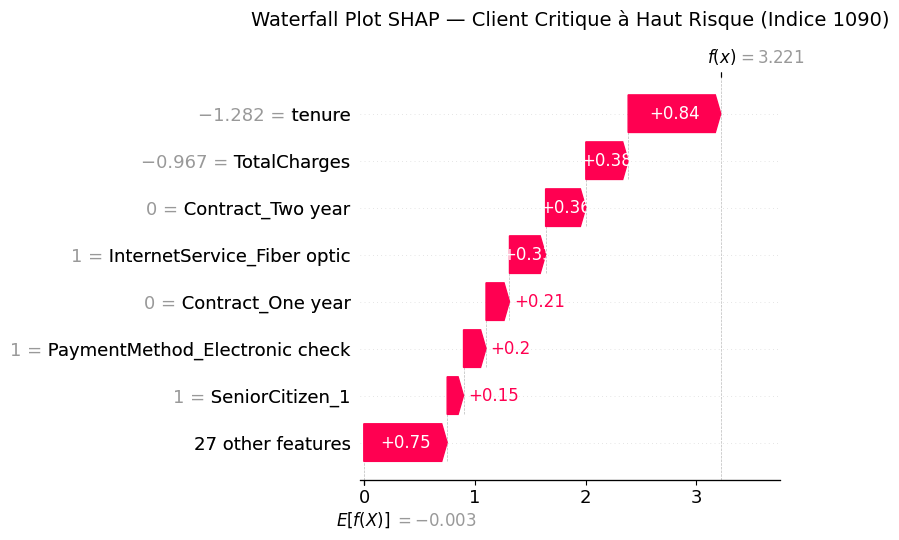

In [6]:
plt.figure(figsize=(12, 5))
plt.title(f"Waterfall Plot SHAP — Client Critique à Haut Risque (Indice {high_risk_idx})", fontsize=14, pad=15)
shap.plots.waterfall(shap_values[high_risk_idx], max_display=8, show=False)
plt.tight_layout()
plt.show()

<center style="background-color: white; padding:18px; color: #1a252f; font-family:'Tw Cen MT' sans-serif; font-size: 20px;">
 <strong> 📝 3. Synthèse d'Interprétation Métier (Style Word/Consulting)</strong> 
</center>

<div style="background-color: #ffffff; 
            padding: 30px 40px; 
            color: #2c3e50; 
            font-family: 'Calibri', 'Segoe UI', Arial, sans-serif; 
            font-size: 16px; 
            line-height: 1.6; 
            text-align: justify; 
            box-shadow: 0 4px 15px rgba(0,0,0,0.05); 
            border-radius: 4px; 
            margin: 20px 0; 
            border-left: 5px solid #2e7d32;">
    <!-- Premier Paragraphe : Corps du texte -->
    <p style="margin-bottom: 20px; text-indent: 30px;">
       Nous allons isoler deux clients réels de ta base de test pour générer des Waterfall Plots. Ces graphiques montrent précisément comment les caractéristiques individuelles s'additionnent ou se soustraient pour créer le score de risque final.
    </p>
 
</div>